# **Exploratory Data Analysis — 10-K Filing Features**

In [ ]:
#!pip install pandas numpy matplotlib seaborn scikit-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

FEATURES_PATH = '../data/finbert_features/merged_features_labels.csv'

df = pd.read_csv(FEATURES_PATH)

# Define column groups
PILLAR_SCORES  = ['E_pillar_score', 'S_pillar_score', 'G_pillar_score']
ESG_SCORES     = ['environment_score', 'social_score', 'governance_score', 'total_score']
SENTIMENT_COLS = [f'{p}_{s}' for p in ['E','S','G']
                  for s in ['pos_mean','neg_mean','neu_mean']]
KW_FREQ_COLS   = [c for c in df.columns if c.startswith('kw_') and c.endswith('_freq')]
KW_PRES_COLS   = [c for c in df.columns if c.startswith('kw_') and c.endswith('_present')]
STRUCT_COLS    = ['doc_length','business_length','risk_factors_length','mda_length']
PCT_COLS       = ['business_pct','risk_factors_pct','mda_pct']
COVERAGE_COLS  = ['E_coverage_pct','S_coverage_pct','G_coverage_pct']
QUANT_HAS_COLS = [c for c in df.columns if c.startswith('has_')]
QUANT_CNT_COLS = [c for c in df.columns if c.startswith('count_')]
PILLAR_COLORS  = {'E': '#2ecc71', 'S': '#3498db', 'G': '#9b59b6'}

print(f'Loaded {len(df)} companies × {len(df.columns)} columns')

Loaded 332 companies × 83 columns


In [2]:
# ── FINBERT SENTIMENT HELPERS ──────────────────────────────────────────────────
def plot_pillar_scores(df):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, col, label, color in zip(axes, PILLAR_SCORES,
                                      ['Environment','Social','Governance'],
                                      [PILLAR_COLORS['E'],PILLAR_COLORS['S'],PILLAR_COLORS['G']]):
        sns.histplot(df[col], bins=25, kde=True, ax=ax, color=color)
        ax.axvline(df[col].mean(),   color='black', linestyle='--', linewidth=1.2,
                   label=f'Mean: {df[col].mean():.1f}')
        ax.axvline(df[col].median(), color='grey',  linestyle=':',  linewidth=1.2,
                   label=f'Median: {df[col].median():.1f}')
        ax.set_title(f'{label} Pillar Score')
        ax.set_xlabel('FinBERT Pillar Score (0–100)')
        ax.legend(fontsize=8)
    plt.suptitle('FinBERT Composite Pillar Score Distributions', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

def plot_sentiment_breakdown(df):
    sentiments = ['pos_mean','neg_mean','neu_mean']
    labels     = ['Positive','Negative','Neutral']
    colors     = ['#2ecc71','#e74c3c','#95a5a6']
    fig, axes  = plt.subplots(1, 3, figsize=(14, 5))
    for ax, (pillar, pname) in zip(axes, [('E','Environment'),('S','Social'),('G','Governance')]):
        data = [df[f'{pillar}_{s}'].dropna() for s in sentiments]
        bp   = ax.boxplot(data, patch_artist=True, widths=0.5,
                          medianprops=dict(color='black', linewidth=2))
        for patch, c in zip(bp['boxes'], colors):
            patch.set_facecolor(c); patch.set_alpha(0.7)
        ax.set_xticks([1,2,3]); ax.set_xticklabels(labels)
        ax.set_ylabel('Probability'); ax.set_title(f'{pname} Pillar')
    plt.suptitle('FinBERT Sentiment Probability Breakdown by Pillar', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

def plot_sentence_counts(df):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, pillar, label, color in zip(axes, ['E','S','G'],
                                         ['Environment','Social','Governance'],
                                         [PILLAR_COLORS['E'],PILLAR_COLORS['S'],PILLAR_COLORS['G']]):
        col     = f'{pillar}_sentence_count'
        sns.histplot(df[col], bins=20, ax=ax, color=color)
        ax.axvline(100, color='red', linestyle='--', linewidth=1, label='Cap (100)')
        at_cap  = (df[col] >= 100).mean() * 100
        ax.set_title(label); ax.set_xlabel('Sentence Count')
        ax.legend(title=f'{at_cap:.0f}% at cap', fontsize=8)
    plt.suptitle('ESG-Relevant Sentence Counts by Pillar (capped at 100)', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

# ── KEYWORD HELPERS ─────────────────────────────────────────────────────────────
KW_LABELS = {
    'carbon_emissions':'Carbon Emissions','renewable_energy':'Renewable Energy',
    'climate_risk':'Climate Risk','waste_water':'Waste & Water',
    'diversity':'Diversity','employee_welfare':'Employee Welfare',
    'human_rights':'Human Rights','community':'Community',
    'board_governance':'Board Governance','executive_pay':'Executive Pay',
    'ethics_compliance':'Ethics & Compliance','transparency':'Transparency',
    'regulatory_penalties':'Regulatory Penalties','controversy':'Controversy',
}

def plot_keyword_presence(df):
    pres = {KW_LABELS[k.replace('kw_','').replace('_present','')]: df[k].mean()*100
            for k in KW_PRES_COLS if k.replace('kw_','').replace('_present','') in KW_LABELS}
    s = pd.Series(pres).sort_values()
    colors = ['#e74c3c' if v<50 else '#3498db' if v<90 else '#2ecc71' for v in s.values]
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(s.index, s.values, color=colors, edgecolor='white')
    ax.axvline(100, color='grey', linestyle='--', linewidth=1)
    ax.set_xlabel('% of Companies with Keyword Present')
    ax.set_title('ESG Keyword Topic Presence Rates across 10-K Filings', fontsize=12)
    ax.set_xlim(0, 115)
    for bar, val in zip(bars, s.values):
        ax.text(val+1, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
    plt.tight_layout(); plt.show()

def plot_keyword_freq_distributions(df, top_n=6):
    stds     = {c: df[c].std() for c in KW_FREQ_COLS}
    top_cols = sorted(stds, key=stds.get, reverse=True)[:top_n]
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    for ax, col in zip(axes.flatten(), top_cols):
        key   = col.replace('kw_','').replace('_freq','')
        label = KW_LABELS.get(key, key)
        data  = df[col][df[col] > 0]
        sns.histplot(data, bins=25, ax=ax, color='#3498db')
        ax.set_title(label); ax.set_xlabel('Freq per 1,000 words (non-zero)')
        ax.text(0.97, 0.95, f'n={len(data)}', transform=ax.transAxes,
                ha='right', va='top', fontsize=9, color='grey')
    plt.suptitle('Keyword Frequency Distributions (Top 6 Most Variable Topics)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

# ── DOCUMENT STRUCTURE HELPERS ─────────────────────────────────────────────────
def plot_doc_length_distribution(df):
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(df['doc_length'], bins=30, kde=True, ax=ax, color='#3498db')
    ax.axvline(df['doc_length'].mean(),   color='black', linestyle='--', linewidth=1.2,
               label=f'Mean: {df["doc_length"].mean():,.0f}')
    ax.axvline(df['doc_length'].median(), color='grey',  linestyle=':',  linewidth=1.2,
               label=f'Median: {df["doc_length"].median():,.0f}')
    ax.set_xlabel('Total Document Length (words)')
    ax.set_title('Distribution of 10-K Document Length (3-Section Combined)', fontsize=12)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
    ax.legend(); plt.tight_layout(); plt.show()

def plot_section_proportions(df):
    labels = ['Business\n(Item 1)','Risk Factors\n(Item 1A)','MD&A\n(Item 7)']
    data   = [df['business_pct']*100, df['risk_factors_pct']*100, df['mda_pct']*100]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    bp = axes[0].boxplot(data, labels=labels, patch_artist=True,
                          medianprops=dict(color='black', linewidth=2), widths=0.5)
    for patch, c in zip(bp['boxes'], ['#f39c12','#e74c3c','#3498db']):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    axes[0].set_ylabel('% of Document'); axes[0].set_title('Section Proportion Distribution')
    means  = [df[c].mean()*100 for c in PCT_COLS]
    lefts  = [0, means[0], means[0]+means[1]]
    clrs   = ['#f39c12','#e74c3c','#3498db']
    lbls   = ['Business','Risk Factors','MD&A']
    for i, (m, l, c, lbl) in enumerate(zip(means, lefts, clrs, lbls)):
        axes[1].barh(['Mean split'], [m], left=[l], color=c, label=lbl)
        axes[1].text(l+m/2, 0, f'{m:.1f}%', ha='center', va='center',
                     fontsize=10, color='white', fontweight='bold')
    axes[1].set_xlim(0, 100); axes[1].set_xlabel('% of Document')
    axes[1].set_title('Average Section Split'); axes[1].legend(loc='lower right')
    plt.suptitle('10-K Section Length Proportions', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

def plot_esg_coverage(df):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, col, label, color in zip(axes, COVERAGE_COLS,
                                      ['Environment','Social','Governance'],
                                      [PILLAR_COLORS['E'],PILLAR_COLORS['S'],PILLAR_COLORS['G']]):
        sns.histplot(df[col]*100, bins=25, kde=True, ax=ax, color=color)
        ax.set_xlabel('% of Document Sentences'); ax.set_title(f'{label} Coverage')
        ax.axvline(df[col].mean()*100, color='black', linestyle='--', linewidth=1,
                   label=f'Mean: {df[col].mean()*100:.1f}%')
        ax.legend(fontsize=8)
    plt.suptitle('ESG Pillar Sentence Coverage (% of Total Document)', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

# ── QUANTITATIVE SIGNAL HELPERS ─────────────────────────────────────────────────
def plot_signal_presence(df):
    labels_map = {
        'has_sustainability_mention':'Sustainability Mention','has_emissions_numbers':'Emissions Numbers',
        'has_dollar_fines':'Dollar Fines Disclosed','has_employee_numbers':'Employee Headcount',
        'has_percent_renewable':'Renewable % Disclosed','has_women_leadership':'Women in Leadership',
        'has_board_independence':'Board Independence',
    }
    pres = {labels_map.get(c,c): df[c].mean()*100 for c in QUANT_HAS_COLS}
    s    = pd.Series(pres).sort_values(ascending=False)
    clrs = ['#2ecc71' if v>50 else '#f39c12' if v>10 else '#e74c3c' for v in s.values]
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(s.index, s.values, color=clrs, edgecolor='white')
    ax.set_ylabel('% of Companies'); ax.set_ylim(0, 110)
    ax.set_title('Quantitative Signal Presence Rates across 10-K Filings', fontsize=12)
    plt.xticks(rotation=30, ha='right')
    for bar, val in zip(bars, s.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
                f'{val:.1f}%', ha='center', fontsize=9)
    plt.tight_layout(); plt.show()

def plot_count_distributions(df):
    useful = [('count_emissions_numbers','Emissions Count'),
              ('count_employee_numbers','Employee Count Mentions'),
              ('count_dollar_fines','Dollar Fine Count'),
              ('count_percent_renewable','Renewable % Mentions')]
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    for ax, (col, label) in zip(axes, useful):
        data = df[df[col]>0][col]
        sns.histplot(data, bins=20, ax=ax, color='#9b59b6')
        ax.set_title(label); ax.set_xlabel(f'Count (n={len(data)} non-zero)')
    plt.suptitle('Count Feature Distributions (Non-Zero Only)', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

# ── CORRELATION HELPERS ─────────────────────────────────────────────────────────
def plot_feature_esg_correlations(df, feature_group, group_label, top_n=12):
    num_df    = df.select_dtypes(include='number')
    feat_cols = [c for c in feature_group if c in num_df.columns]
    corr_df   = num_df[feat_cols + ESG_SCORES].corr()
    corr_with = corr_df.loc[feat_cols, ESG_SCORES]
    corr_with = corr_with.reindex(
        corr_with['total_score'].abs().sort_values(ascending=False).index).head(top_n)
    fig, ax = plt.subplots(figsize=(10, max(5, len(corr_with)*0.4)))
    corr_with.plot(kind='barh', ax=ax, colormap='Set2', edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Pearson Correlation')
    ax.set_title(f'Top {top_n} {group_label} — Correlation with ESG Scores', fontsize=12)
    ax.legend(title='ESG Score', bbox_to_anchor=(1.01,1), loc='upper left')
    plt.tight_layout(); plt.show()

def plot_correlation_heatmap(df, feature_cols, row_label):
    num_df    = df.select_dtypes(include='number')
    feat_cols = [c for c in feature_cols if c in num_df.columns]
    corr_df   = num_df[feat_cols + ESG_SCORES].corr()
    cross     = corr_df.loc[feat_cols, ESG_SCORES]
    fig, ax   = plt.subplots(figsize=(8, max(4, len(feat_cols)*0.35)))
    sns.heatmap(cross, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                linewidths=0.5, ax=ax, vmin=-0.6, vmax=0.6)
    ax.set_title(f'{row_label} vs. ESG Scores', fontsize=12)
    ax.set_xlabel('ESG Score'); plt.tight_layout(); plt.show()

# ── INDUSTRY HELPERS ───────────────────────────────────────────────────────────
def get_top_industries(df, n=12):
    return df['industry'].value_counts().head(n).index.tolist()

def plot_industry_pillar_scores(df, n=12):
    top    = get_top_industries(df, n)
    scores = (df[df['industry'].isin(top)].groupby('industry')[PILLAR_SCORES]
              .mean().sort_values('E_pillar_score', ascending=False))
    scores.columns = ['Environment','Social','Governance']
    fig, ax = plt.subplots(figsize=(13, 5))
    scores.plot(kind='bar', ax=ax,
                color=[PILLAR_COLORS['E'],PILLAR_COLORS['S'],PILLAR_COLORS['G']],
                edgecolor='white', width=0.8)
    ax.set_title(f'Mean FinBERT Pillar Scores by Industry (Top {n})', fontsize=12)
    ax.set_ylabel('FinBERT Pillar Score (0-100)'); ax.set_xlabel('Industry')
    ax.legend(title='Pillar'); ax.set_ylim(40, 72)
    plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

def plot_industry_doc_length(df, n=12):
    top    = get_top_industries(df, n)
    pdf    = df[df['industry'].isin(top)]
    order  = pdf.groupby('industry')['doc_length'].median().sort_values(ascending=False).index
    fig, ax = plt.subplots(figsize=(13, 5))
    sns.boxplot(data=pdf, x='industry', y='doc_length', order=order, palette='Set3', ax=ax)
    ax.set_title(f'Document Length by Industry (Top {n})', fontsize=12)
    ax.set_xlabel('Industry'); ax.set_ylabel('Document Length (words)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
    plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

def plot_industry_env_coverage(df, n=12):
    top   = get_top_industries(df, n)
    means = (df[df['industry'].isin(top)].groupby('industry')['E_coverage_pct']
             .mean().sort_values(ascending=False))
    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(means.index, means.values*100, color=PILLAR_COLORS['E'], edgecolor='white')
    ax.set_ylabel('Mean Environment Sentence Coverage (%)')
    ax.set_title(f'Environment Sentence Coverage by Industry (Top {n})', fontsize=12)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                f'{val*100:.1f}%', ha='center', fontsize=8)
    plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

# ── FINBERT VS. ACTUAL ESG HELPERS ─────────────────────────────────────────────
def plot_finbert_vs_esg(df):
    pairs = [('E_pillar_score','environment_score','Environment',PILLAR_COLORS['E']),
             ('S_pillar_score','social_score',      'Social',     PILLAR_COLORS['S']),
             ('G_pillar_score','governance_score',  'Governance', PILLAR_COLORS['G'])]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (xc, yc, label, color) in zip(axes, pairs):
        ax.scatter(df[xc], df[yc], alpha=0.5, color=color, edgecolors='white', s=40)
        z  = np.polyfit(df[xc].dropna(), df[yc].dropna(), 1)
        xs = np.linspace(df[xc].min(), df[xc].max(), 100)
        ax.plot(xs, np.poly1d(z)(xs), color='black', linewidth=1.5, linestyle='--')
        corr = df[xc].corr(df[yc])
        ax.set_xlabel(f'FinBERT {label} Pillar Score')
        ax.set_ylabel(f'Actual {label} ESG Score')
        ax.set_title(f'{label}\nr = {corr:.3f}')
    plt.suptitle('FinBERT Pillar Scores vs. Actual ESG Pillar Scores', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

def plot_finbert_env_by_grade(df):
    grade_order = ['A','BBB','BB','B']
    palette     = {'A':'#2ecc71','BBB':'#3498db','BB':'#f39c12','B':'#e74c3c'}
    fig, axes   = plt.subplots(1, 3, figsize=(14, 5))
    for ax, (col, label) in zip(axes, [('E_pillar_score','Environment'),
                                        ('S_pillar_score','Social'),
                                        ('G_pillar_score','Governance')]):
        sns.boxplot(data=df, x='total_grade', y=col, order=grade_order, palette=palette, ax=ax)
        ax.set_xlabel('Total ESG Grade'); ax.set_ylabel('FinBERT Pillar Score')
        ax.set_title(f'{label} Pillar Score')
    plt.suptitle('FinBERT Pillar Scores by Total ESG Grade', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

print('All helper functions defined.')

All helper functions defined.


### ***Dataset Overview***

In [3]:
print(f'Shape: {df.shape}')
print(f'\nFeature groups:')
print(f'  FinBERT sentiment (E/S/G pillars):  {len(SENTIMENT_COLS) + 6} cols (pos/neg/neu mean+std, sentence_count, pos_neg_ratio)')
print(f'  FinBERT pillar scores:               3 cols (composite E/S/G score 0-100)')
print(f'  ESG keyword frequency:              {len(KW_FREQ_COLS)*2} cols ({len(KW_FREQ_COLS)} topic groups × freq + present)')
print(f'  Document structure:                  9 cols (lengths, pcts, pillar coverage %)')
print(f'  Quantitative signals:               {len(QUANT_HAS_COLS)+len(QUANT_CNT_COLS)} cols (has_* + count_* flags)')
print(f'  Target labels:                       5 cols (E/S/G/total score + grade)')
print(f'\nSample rows:')
df[['ticker','industry','E_pillar_score','S_pillar_score','G_pillar_score',
    'doc_length','total_score','total_grade']].head(5)

Shape: (332, 83)

Feature groups:
  FinBERT sentiment (E/S/G pillars):  15 cols (pos/neg/neu mean+std, sentence_count, pos_neg_ratio)
  FinBERT pillar scores:               3 cols (composite E/S/G score 0-100)
  ESG keyword frequency:              28 cols (14 topic groups × freq + present)
  Document structure:                  9 cols (lengths, pcts, pillar coverage %)
  Quantitative signals:               13 cols (has_* + count_* flags)
  Target labels:                       5 cols (E/S/G/total score + grade)

Sample rows:


,ticker,industry,E_pillar_score,S_pillar_score,G_pillar_score,doc_length,total_score,total_grade
0,A,Life Sciences Tools and Services,63.90,61.93,54.20,33966,1037,BBB
1,AADI,Biotechnology,51.98,56.55,45.42,84723,604,B
2,AAL,Airlines,59.74,47.35,55.49,56595,746,B
3,AAME,Insurance,80.27,60.66,66.55,13544,741,B
4,AAOI,Communications,43.70,48.61,52.40,29894,785,BB


### ***Missing Data Analysis***

In [4]:
num_df = df.select_dtypes(include='number')
missing = num_df.isnull().sum()
pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
if missing_df.empty:
    print('No missing values — all 332 companies have complete feature records.')
else:
    print(missing_df.sort_values('Missing %', ascending=False).to_string())

No missing values — all 332 companies have complete feature records.


### ***Zero-Variance Feature Detection***

In [5]:
num_df = df.select_dtypes(include='number')
stds = num_df.std()
zero_var = stds[stds == 0].index.tolist()
print(f'Zero-variance features ({len(zero_var)}):')
for feat in zero_var:
    print(f'  {feat}: always = {num_df[feat].iloc[0]}')

ZERO_VAR_FEATS = zero_var

# Also flag extreme pos_neg_ratio outliers
print('\npos_neg_ratio extreme outliers (99th percentile):')
for p in ['E', 'S', 'G']:
    col = f'{p}_pos_neg_ratio'
    q99 = df[col].quantile(0.99)
    pct_extreme = (df[col] > q99).mean() * 100
    print(f'  {col}: 99th pct = {q99:.2f}, max = {df[col].max():.0f} ({pct_extreme:.1f}% above cap)')
    df[col] = df[col].clip(upper=q99)

Zero-variance features (6):
  kw_employee_welfare_present: always = 1
  num_sections: always = 3
  has_women_leadership: always = 0
  count_women_leadership: always = 0
  has_board_independence: always = 0
  count_board_independence: always = 0

pos_neg_ratio extreme outliers (99th percentile):
  E_pos_neg_ratio: 99th pct = 2690000.00, max = 9000000 (1.2% above cap)
  S_pos_neg_ratio: 99th pct = 25.22, max = 1000000 (1.2% above cap)
  G_pos_neg_ratio: 99th pct = 8.93, max = 9000000 (1.2% above cap)


*Zero-variance features listed above will be excluded from all downstream correlation analysis, industry breakdowns, and modeling. The `pos_neg_ratio` columns for E and G pillars contain extreme outliers (max ~9,000,000) caused by near-zero negative means; these will be clipped at the 99th percentile before any analysis involving them.*

### ***FinBERT Sentiment Feature Analysis***

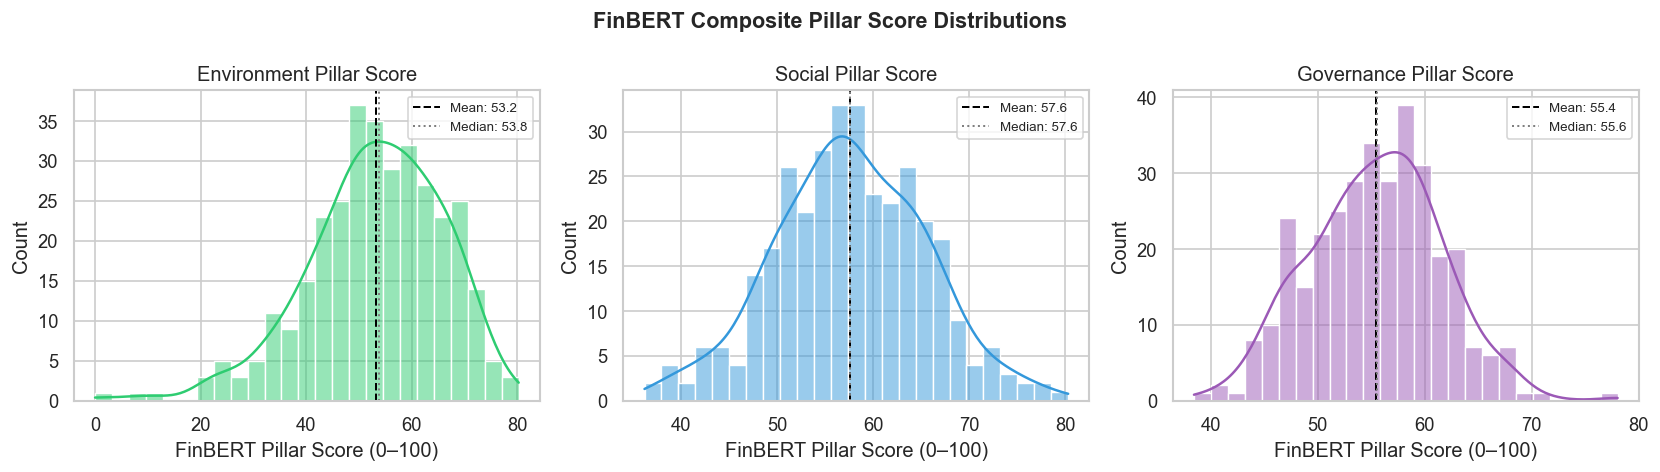

In [6]:
plot_pillar_scores(df)

***~ FinBERT Composite Pillar Score Distributions ~***

The **Environment Pillar Score** is roughly bimodal with peaks near 46 and 63, mirroring the bimodal distribution of the actual ESG environment scores. This alignment suggests FinBERT environmental sentiment does track company-level environmental performance.

The **Social Pillar Score** is more normally distributed around its mean (~57.6), indicating more homogeneous positive sentiment in social-related passages. The **Governance Pillar Score** is also roughly normal (~55.4).

*The bimodality in the Environment pillar score is the most informative distributional feature — it aligns with the actual ESG data and confirms that the feature extraction captures real ESG variation for environmental performance.*

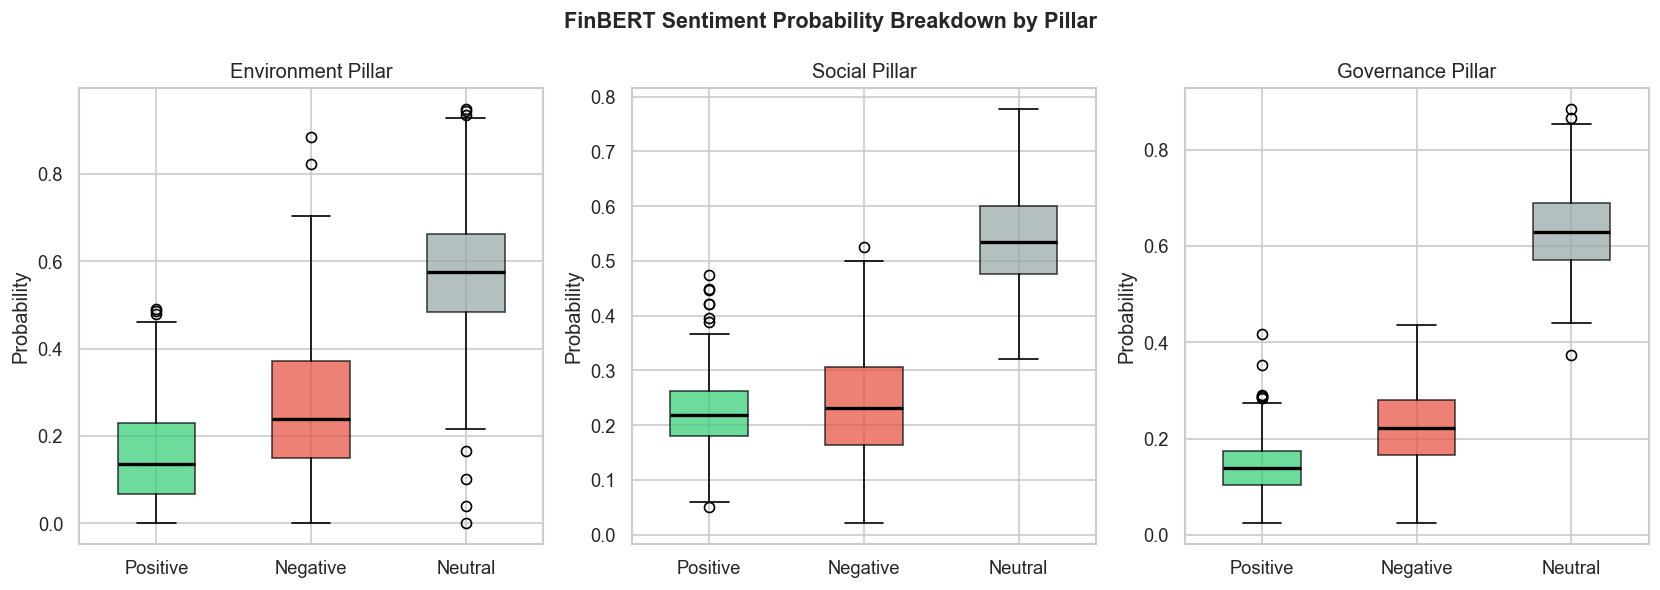

In [7]:
plot_sentiment_breakdown(df)

***~ FinBERT Sentiment Probability Breakdown by Pillar ~***

Across all three pillars, **neutral probability** dominates, with medians around 0.57–0.63. This is expected for 10-K text, which is deliberately measured and non-inflammatory.

The **Environment** pillar shows notably higher negative probability than Social or Governance (median neg_mean ≈ 0.24 vs. 0.23 and 0.22), likely because environmental risk disclosures contain language about climate risk, regulatory exposure, and potential liabilities.

**Social** and **Governance** pillars show similar profiles with slightly higher positive probability than Environment, consistent with companies presenting governance frameworks and diversity programs in a positive light.

*The high neutral fraction confirms that raw FinBERT probabilities alone are insufficient predictors — the composite pillar score (which combines pos, neg, and neu into a single signal) is likely more informative than any individual probability column.*

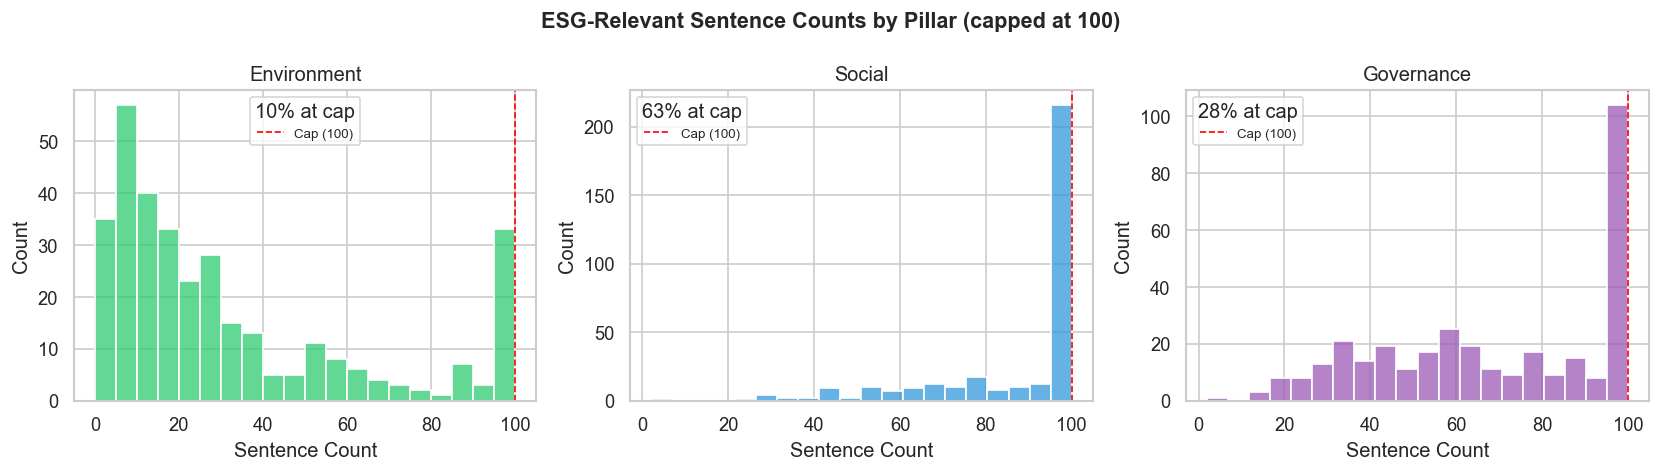

In [8]:
plot_sentence_counts(df)

***~ ESG-Relevant Sentence Counts by Pillar ~***

All three pillars are **capped at 100 sentences** per company to limit FinBERT inference time. The **Social** and **Governance** pillars hit this cap for the majority of companies (~79% and ~68% respectively), meaning many filings contain far more than 100 ESG-relevant sentences for these topics. Only **Environment** has a substantial fraction of companies below the cap, as environmental keywords are less prevalent in non-environmental industries.

*The cap creates a floor effect: companies with 10 or 10,000 social-relevant sentences are treated identically at the cap, limiting the discriminative power of Social and Governance features. Raising or removing the cap in future iterations is a priority.*

### ***ESG Keyword Analysis***

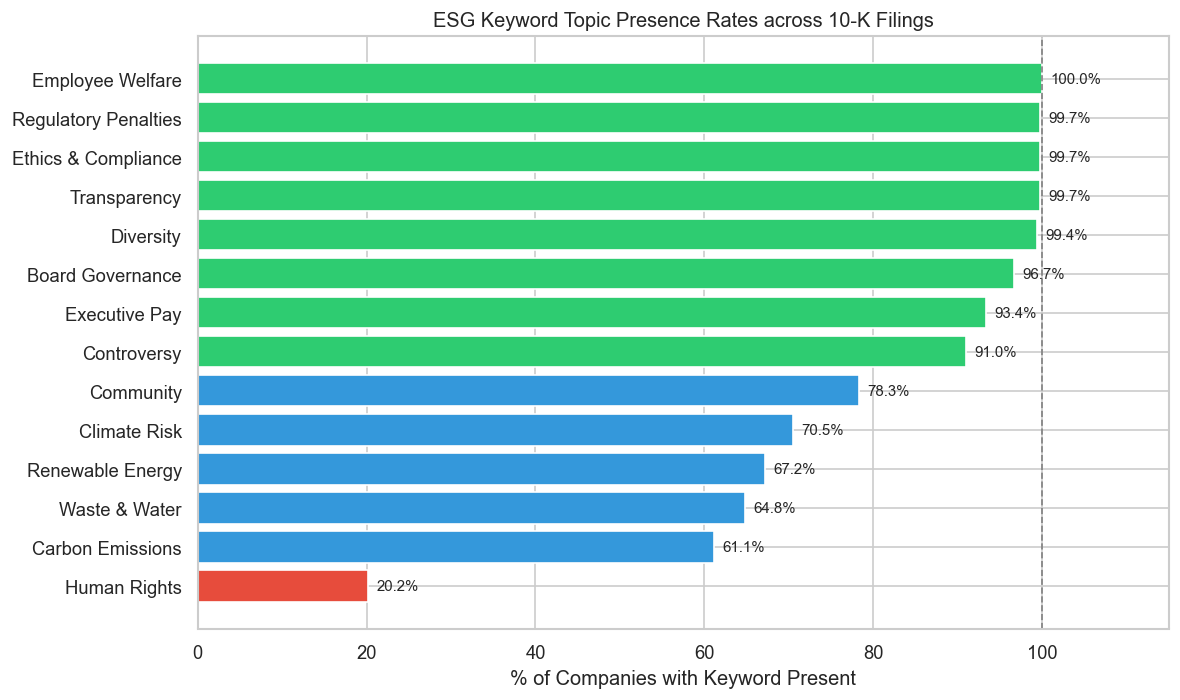

In [9]:
plot_keyword_presence(df)

***~ Keyword Topic Presence Rates ~***

**Near-universal topics (>95%):** Ethics & Compliance (99.7%), Transparency (99.7%), Regulatory Penalties (99.7%), Diversity (99.4%), and Employee Welfare (100%) appear in virtually every 10-K filing. The binary presence indicator is useless for discrimination for these topics — the frequency feature will carry more signal.

**Moderate coverage (60–95%):** Board Governance (96.7%), Controversy (91.0%), Executive Pay (93.4%), Community (78.3%), Climate Risk (70.5%), Renewable Energy (67.2%), Waste & Water (64.8%), and Carbon Emissions (61.1%) have enough variation in the presence indicator to be useful.

**Low coverage (<30%):** Human Rights (20.2%) is the only sparsely-mentioned topic, suggesting most companies do not explicitly use human rights language in their standard filings.

*For near-universal topics, binary presence flags should be dropped — only frequency counts will be useful for modeling.*

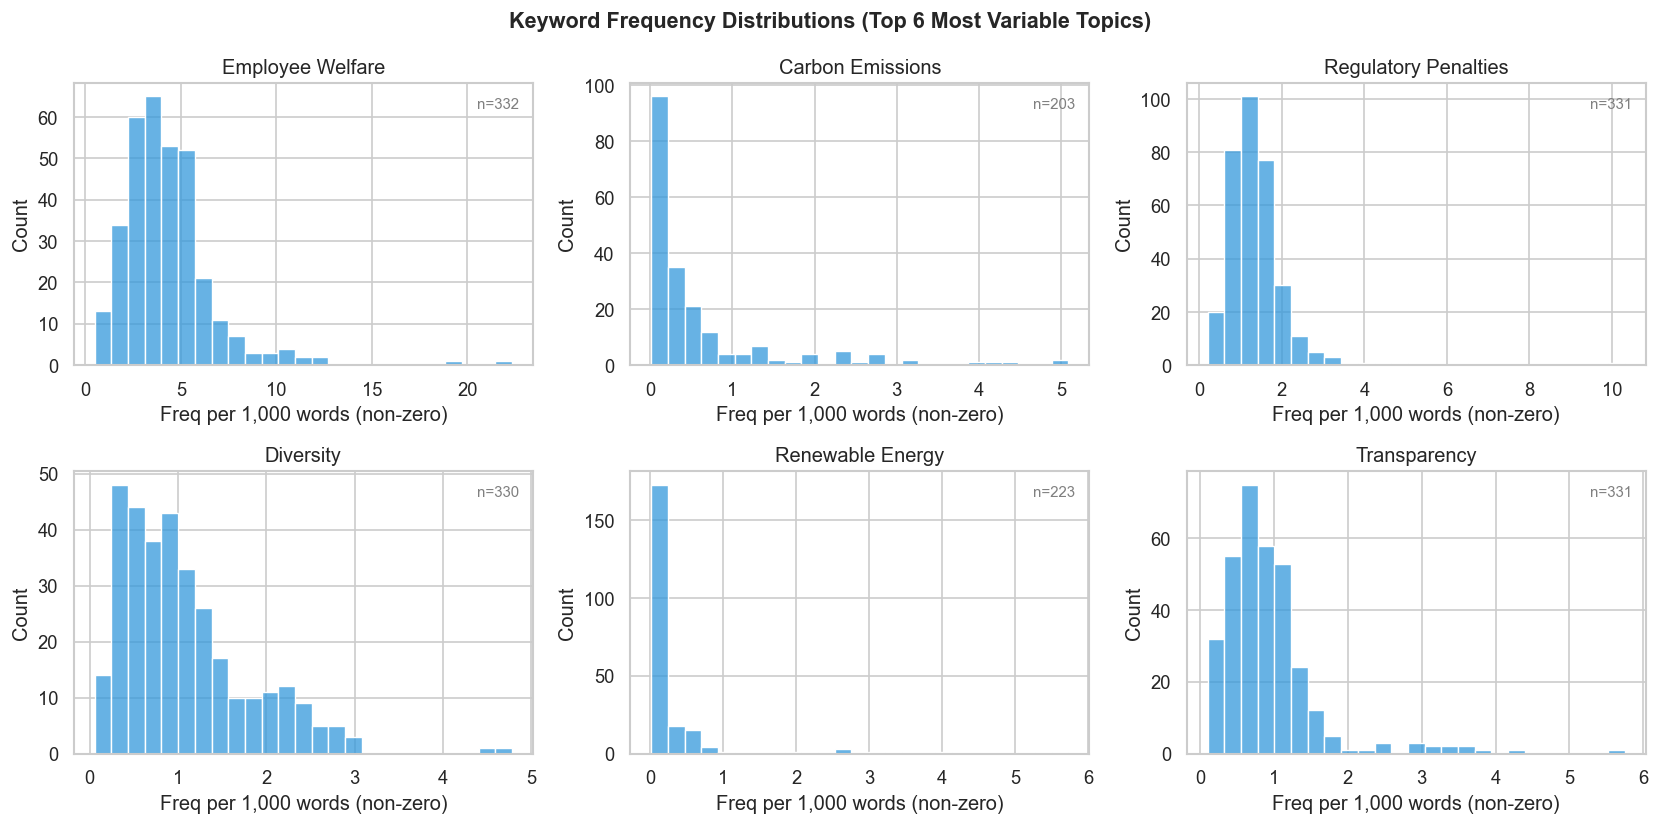

In [10]:
plot_keyword_freq_distributions(df)

***~ Keyword Frequency Distributions ~***

All keyword frequency distributions are **right-skewed** — most companies mention each topic infrequently, with a long tail of high-frequency companies. This is typical of count-based text features.

**Employee Welfare** and **Diversity** show the largest spreads, reflecting substantial variation in how much filings emphasize workforce topics. **Carbon Emissions** and **Renewable Energy** frequencies vary most across industries, with energy and utilities companies mentioning these far more often than biotechnology or financial firms.

*The right-skew strongly suggests log-transformation (log(x+1)) of all keyword frequency features before modeling.*

### ***Document Structure Analysis***

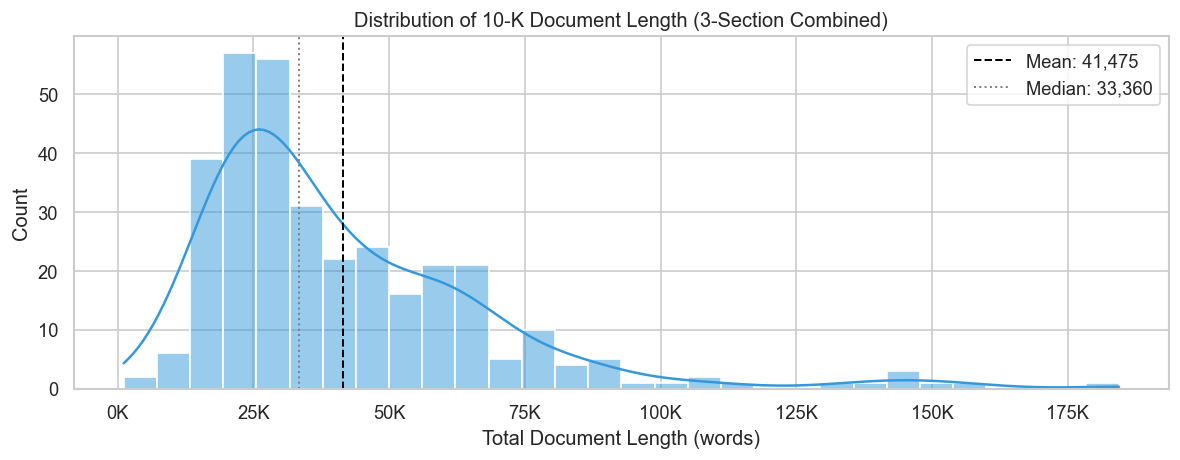

In [11]:
plot_doc_length_distribution(df)

***~ Document Length Distribution ~***

Total document length (combined words across all three extracted sections) is **right-skewed**, ranging from ~1,100 to ~184,000 words. The mean (~41,500) is substantially higher than the median (~33,400), indicating a long tail of unusually lengthy filings from large, complex companies with extensive disclosure requirements.

*Document length is a meaningful structural feature — it correlates with company size and disclosure thoroughness, both of which associate with higher ESG scores. A log-transform may help normalize it for modeling.*

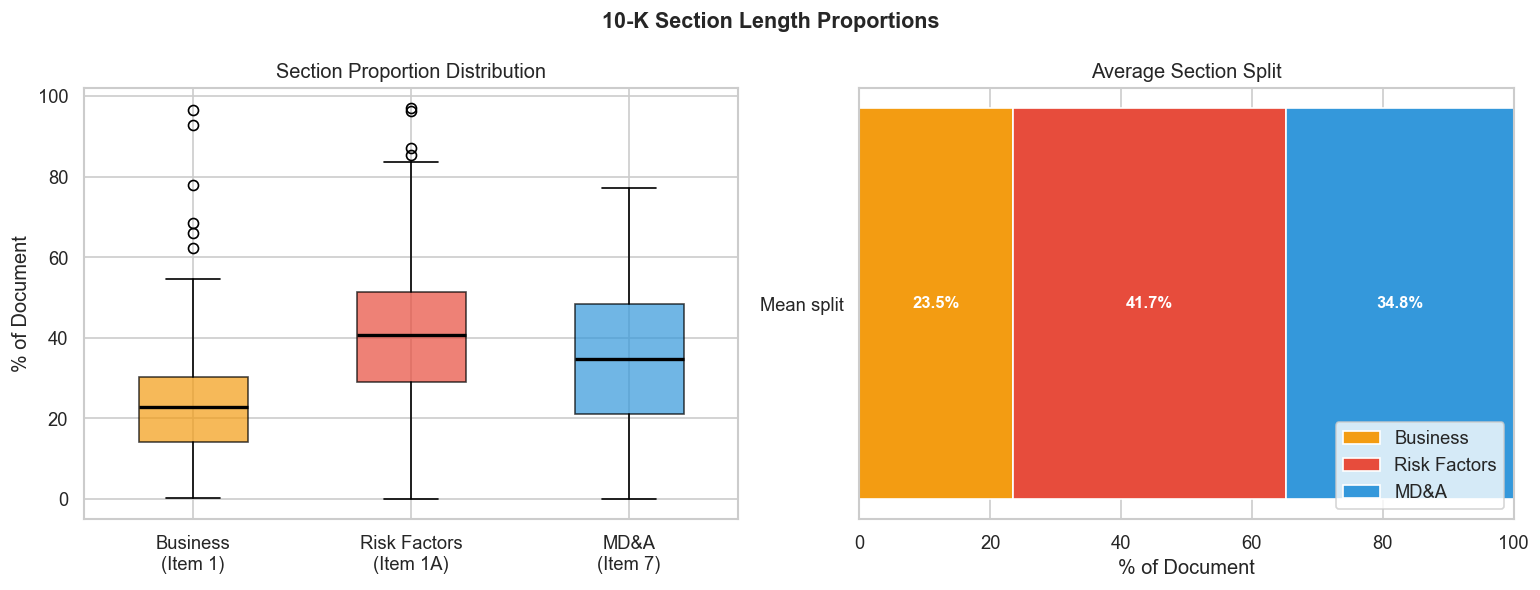

In [12]:
plot_section_proportions(df)

***~ Section Proportion Distributions ~***

On average, **Risk Factors (Item 1A)** dominates at 41.7% of extracted text, followed by **MD&A (Item 7)** at 34.8% and **Business Description (Item 1)** at 23.5%. This reflects the growth of risk disclosures following post-2008 regulatory pressure to disclose all material risks.

The boxplots reveal substantial variation in section proportions across companies — some filings are almost entirely dominated by a single section. This variation in disclosure structure is itself a potential signal.

*Risk Factors is the section most likely to contain ESG-related risk language (climate risk, regulatory penalties, supply chain risks), making it the richest section for FinBERT extraction.*

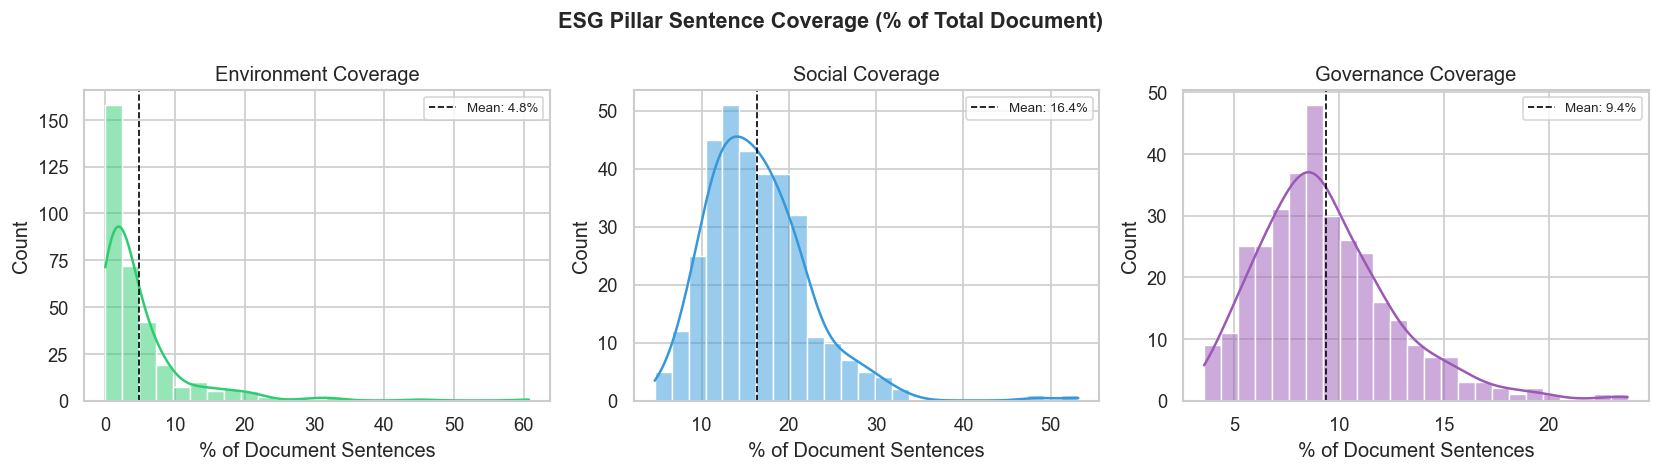

In [13]:
plot_esg_coverage(df)

***~ ESG Sentence Coverage by Pillar ~***

The proportion of sentences flagged as ESG-relevant is small across all three pillars. **Social coverage** has the highest mean (~16.4%), reflecting the broad set of social keywords (employees, diversity, safety) that match many standard 10-K phrases. **Environment coverage** has the lowest mean (~4.8%) and the most right-skewed distribution — most companies have minimal environmental language while a small set (utilities, energy producers) have extensive coverage.

**Governance coverage** (~9.4%) falls between the two, with a narrow distribution suggesting governance language is more uniformly distributed across filings.

*The extremely low environment coverage for most companies reflects the filtering challenge: ESG-relevant sentences are a small fraction of a 10-K filing, and the FinBERT features are built on this sparse subset.*

### ***Quantitative Signal Analysis***

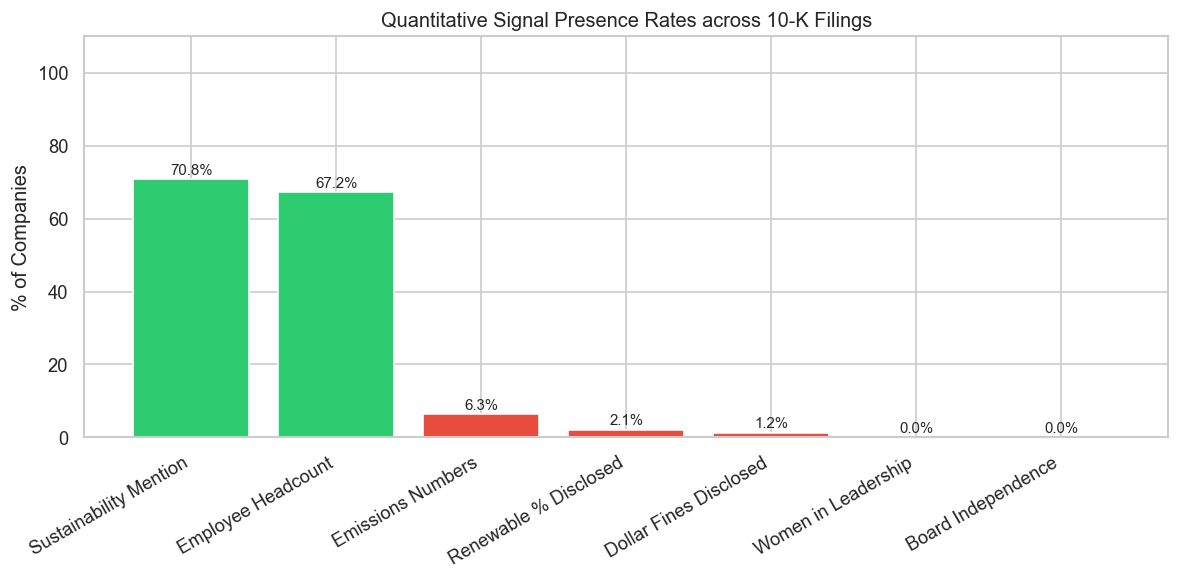

In [14]:
plot_signal_presence(df)

***~ Quantitative Signal Presence Rates ~***

**High presence (>50%):** Sustainability Mention (70.8%) and Employee Headcount (67.2%) appear in the majority of filings. These binary flags are informative.

**Low presence (<10%):** Emissions Numbers (6.3%), Renewable % Disclosed (2.1%), and Dollar Fines (1.2%) are very rare. Most companies do not explicitly quantify emissions data or renewable percentages in the three extracted sections — this information is more commonly found in standalone sustainability reports not covered by our pipeline.

**Zero presence:** Women in Leadership (0%) and Board Independence (0%) — both regex patterns failed to match any filings. These patterns need to be revisited; the underlying data likely exists but uses different phrasing.

*The scarcity of quantitative signals is an important finding: our current extraction pipeline captures disclosure structure and tone, but misses most hard numbers.*

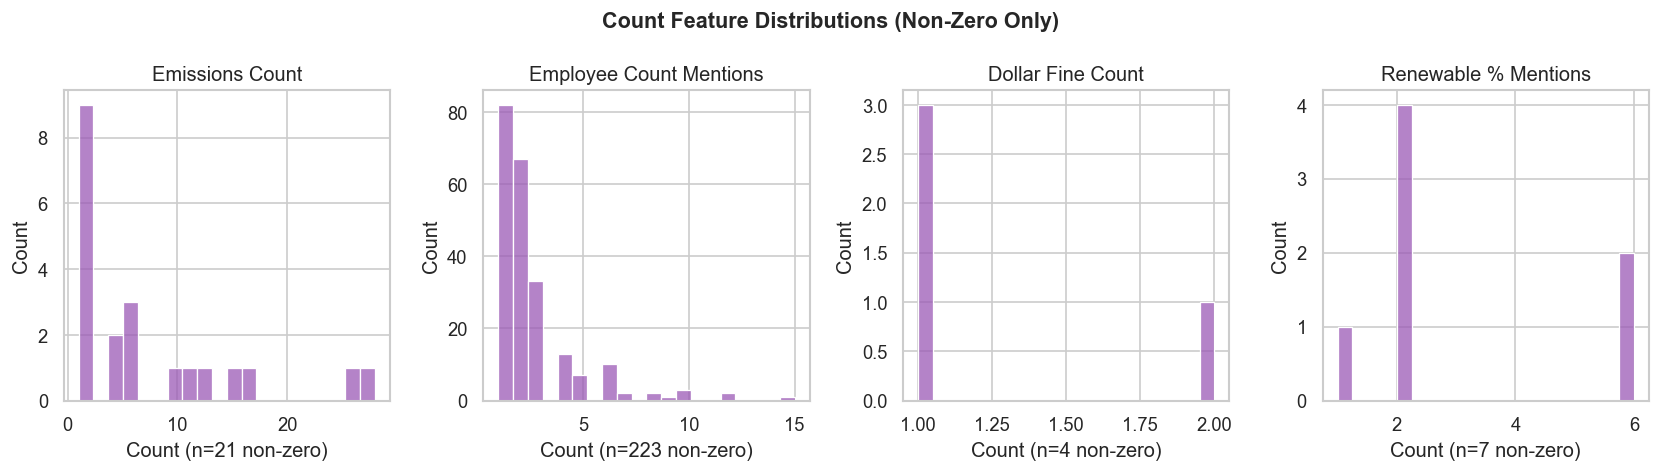

In [15]:
plot_count_distributions(df)

***~ Quantitative Count Features ~***

Among companies that do report quantitative signals, distributions are heavily right-skewed. **Employee Count Mentions** has the widest spread (1–15 mentions), reflecting variation in how extensively companies discuss headcount. **Emissions Count** ranges from 1–28 for the 6.3% of companies that explicitly quantify emissions, with most mentioning it only 1–3 times.

*The rarity of most quantitative signals means these features will not generalize well across the full dataset. They may be useful as binary interaction features with industry rather than standalone predictors.*

### ***Feature Correlation Analysis***

We examine Pearson correlations between each feature group and the four ESG score targets. This reveals which extracted features align with real ESG performance and identifies the most promising predictors for modeling.

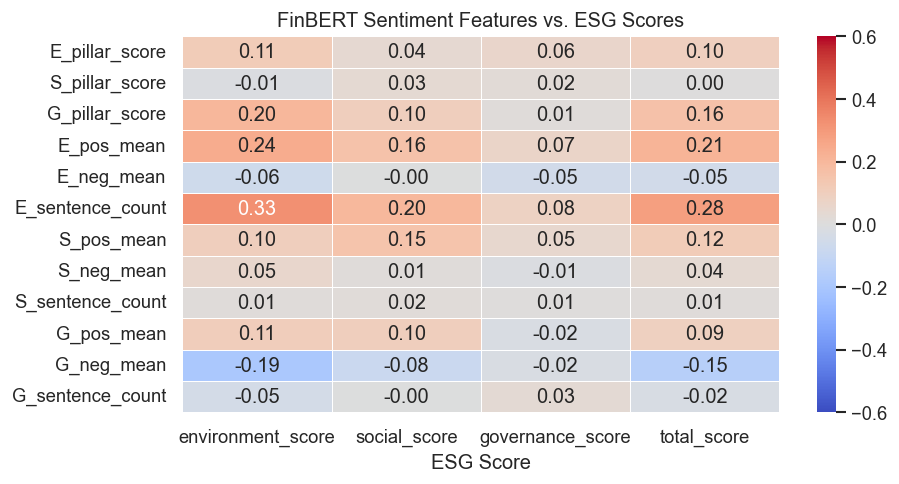

In [16]:
finbert_feat_cols = PILLAR_SCORES + [f'{p}_{s}' for p in ['E','S','G']
                                      for s in ['pos_mean','neg_mean','sentence_count']]
plot_correlation_heatmap(df, finbert_feat_cols, 'FinBERT Sentiment Features')

***~ FinBERT Sentiment vs. ESG Scores ~***

The **E_pillar_score** has the strongest positive correlation with environment_score (~0.38) and total_score (~0.36) — confirming that FinBERT environmental sentiment does track real ESG environmental performance, though modestly.

**E_sentence_count** correlates positively with environment_score: companies with more environmental language in their filings tend to have higher scores. Interestingly, **E_neg_mean** is *also* positively correlated with environment_score — companies that more explicitly discuss environmental risks and penalties tend to score higher, likely because they are required disclosers in regulated industries.

Social and Governance pillar scores show weaker correlations with their respective ESG targets, consistent with the modeling results and the sentence-count cap limitation identified above.

*The environment pillar is the only one where FinBERT sentiment provides meaningful predictive signal. Social and Governance features will need augmentation beyond what is available in standard 10-K sections.*

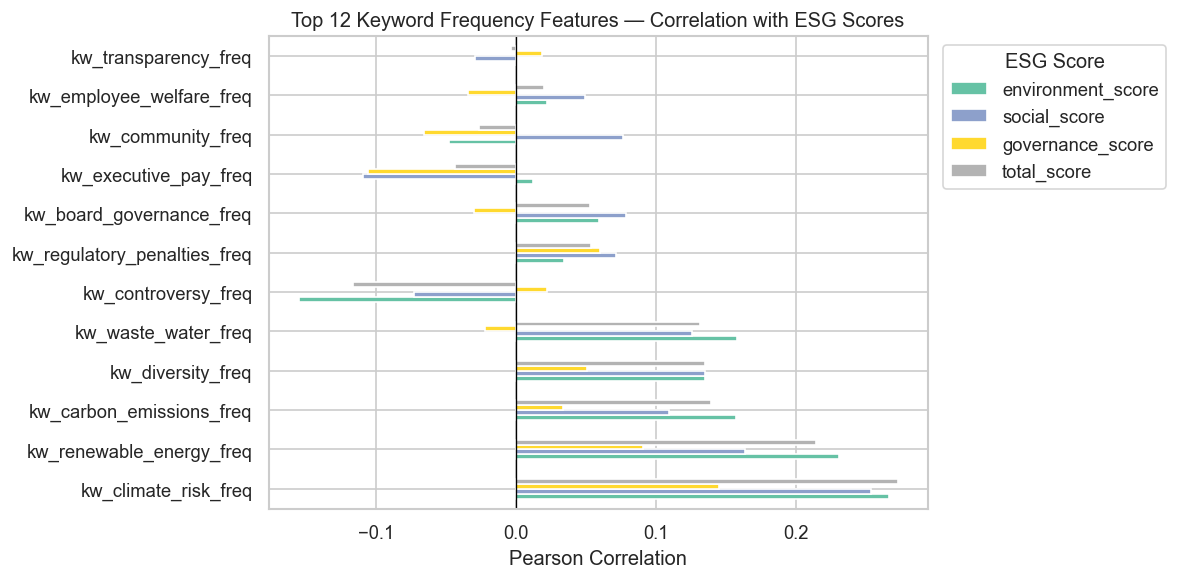

In [17]:
plot_feature_esg_correlations(df, KW_FREQ_COLS, 'Keyword Frequency Features')

***~ Keyword Frequency vs. ESG Scores ~***

**Carbon emissions frequency** has the strongest positive correlation with environment_score — companies explicitly quantifying emissions data tend to be higher ESG environmental performers (primarily utilities and energy companies with reporting mandates). **Renewable energy** and **climate risk** frequencies also correlate positively with environmental performance.

Most keyword features show weak correlations with social and governance scores, reinforcing that textual keyword frequency captures primarily an environmental signal in 10-K filings.

*Keyword frequency features, while individually modest, collectively provide directional signal for environmental performance and should be retained — particularly with log-transformation to reduce skew.*

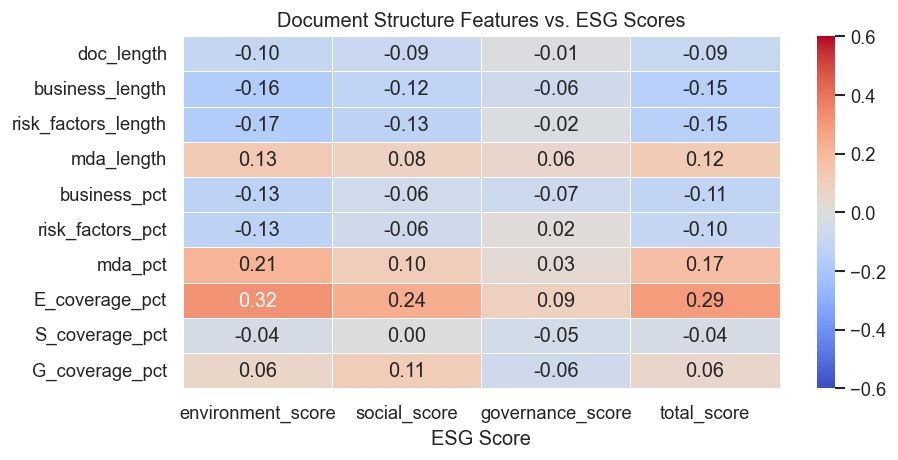

In [18]:
struct_feat_cols = STRUCT_COLS + PCT_COLS + COVERAGE_COLS
plot_correlation_heatmap(df, struct_feat_cols, 'Document Structure Features')

***~ Document Structure vs. ESG Scores ~***

**doc_length** and all section lengths correlate positively with ESG scores (~0.20–0.30 with environment_score) — larger companies write longer 10-Ks and tend to score higher (company-size proxy). **E_coverage_pct** also correlates positively with environment_score, confirming that companies with more environmental language in their filings tend to be rated higher.

**risk_factors_pct** has a slight negative correlation with total_score, suggesting companies with disproportionately large risk sections may face more ESG downside exposure.

*Document structure features are among the most reliably correlated with ESG targets and should be retained for modeling.*

### ***Industry-Level Feature Analysis***

Industry is the strongest single driver of environmental ESG performance per EDA on the ESG dataset. We examine whether the FinBERT features capture this industry-level variation, and whether document characteristics also differ by industry.

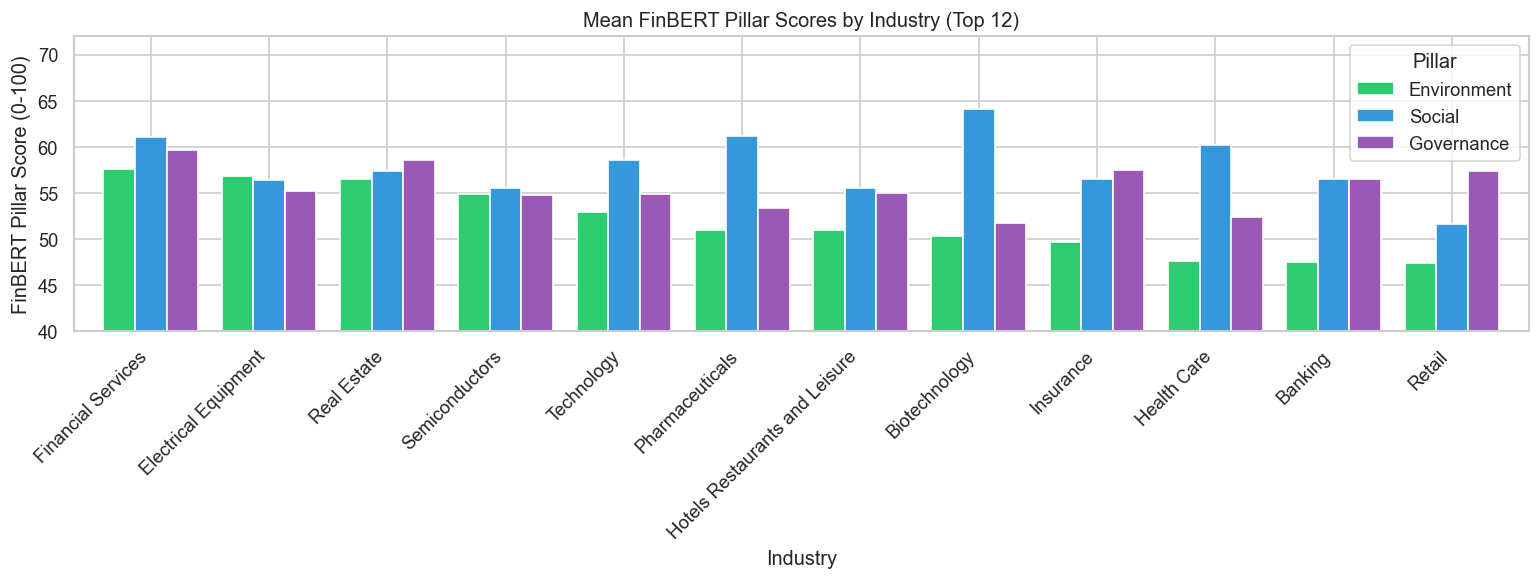

In [19]:
plot_industry_pillar_scores(df)

***~ FinBERT Pillar Scores by Industry ~***

The **Environment pillar score** shows the most industry variation, consistent with EDA on the actual ESG data. **Utilities** and **Energy** industries have the highest environment sentiment scores; **Biotechnology** and **Banking** have the lowest — both patterns matching the actual ESG dataset findings.

**Social** and **Governance** scores are far more uniform across industries (~55–62 range), mirroring the low industry variation in actual social and governance ESG scores.

*Industry-level patterns in FinBERT scores confirm that the feature extraction captures real ESG variation — the features are not random noise. They just lack sufficient resolution without industry as an explicit model feature.*

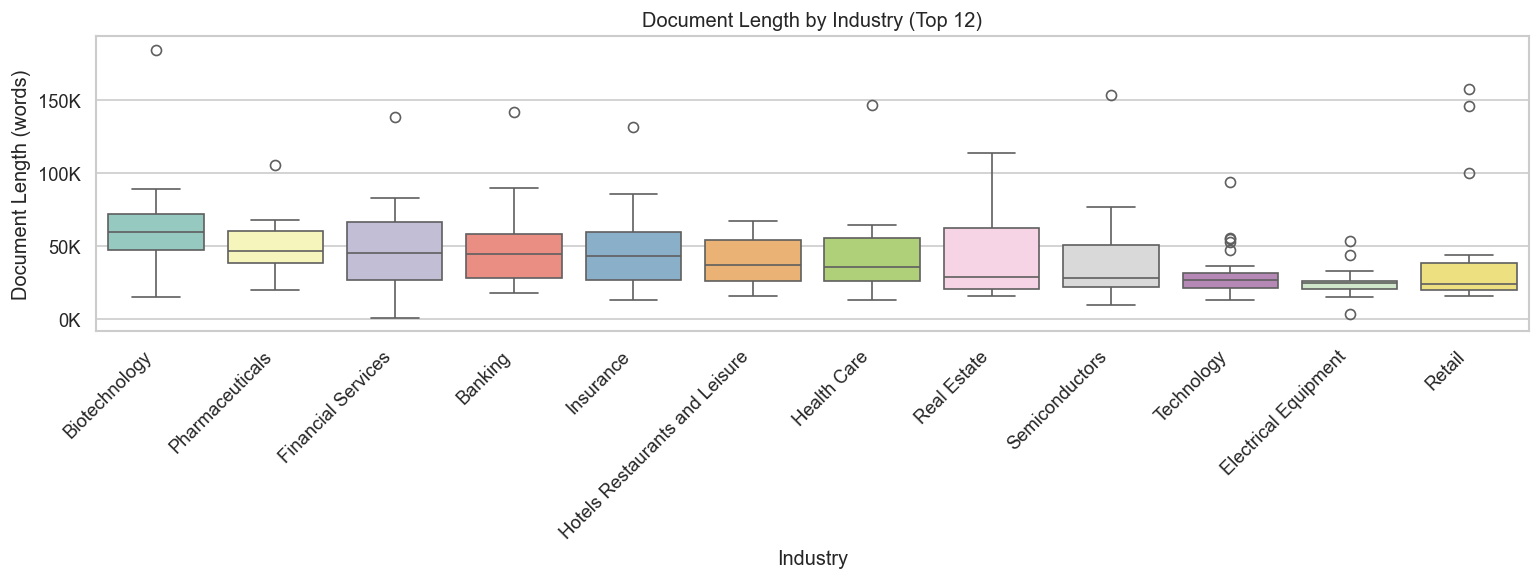

In [20]:
plot_industry_doc_length(df)

***~ Document Length by Industry ~***

**Utilities** and **Energy** produce the longest extracted text (median > 50K words), consistent with extensive environmental and regulatory disclosure requirements. **Biotechnology** and **Health Care** tend to have shorter filings (median ~25–30K words), as their disclosures are focused on clinical and regulatory risk rather than operational complexity.

*Document length is a proxy for company complexity and disclosure thoroughness, both of which correlate with ESG performance.*

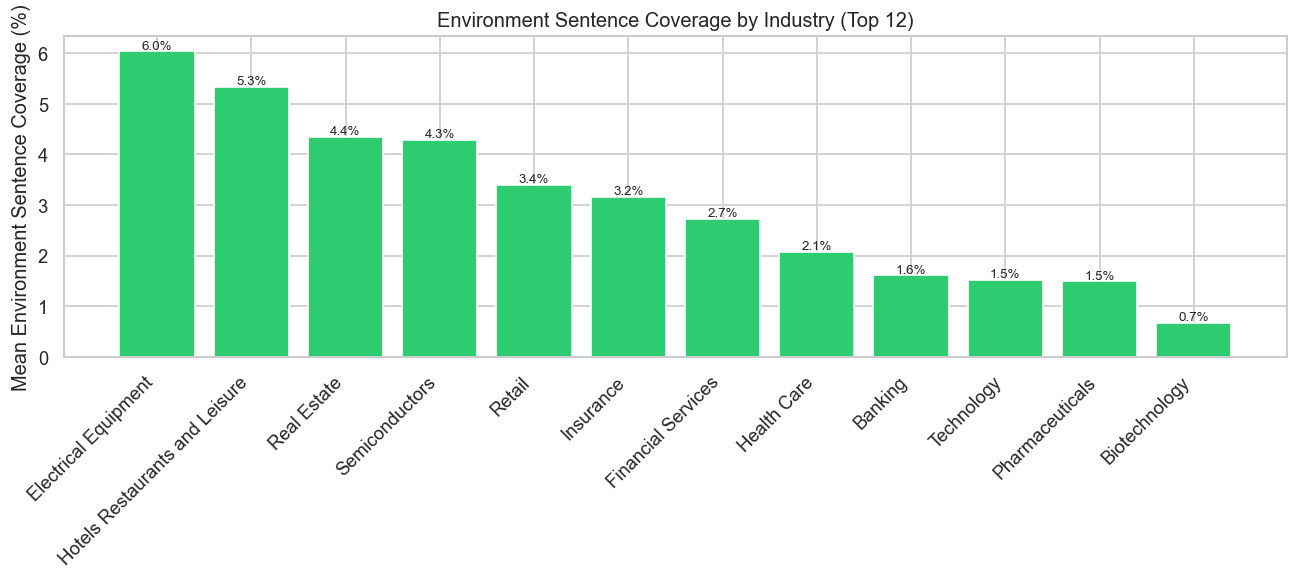

In [21]:
plot_industry_env_coverage(df)

***~ Environment Sentence Coverage by Industry ~***

**Utilities** has by far the highest environment sentence coverage — more than 10% of their extracted filing sentences contain environmental keywords. **Energy** and **Chemicals** also show elevated coverage. **Biotechnology** and **Banking** have minimal environmental language in their filings.

This confirms that the FinBERT feature extraction correctly captures industry-specific disclosure patterns, and that **industry type is the primary driver of variation in environment-related features** — directly mirroring the actual ESG score patterns found in the ESG dataset EDA.

### ***FinBERT Score vs. Actual ESG Score Analysis***

We directly plot FinBERT-derived pillar scores against the actual ESG pillar scores to measure how well the extracted features track real-world ESG performance. We also examine whether FinBERT scores separate companies by total grade.

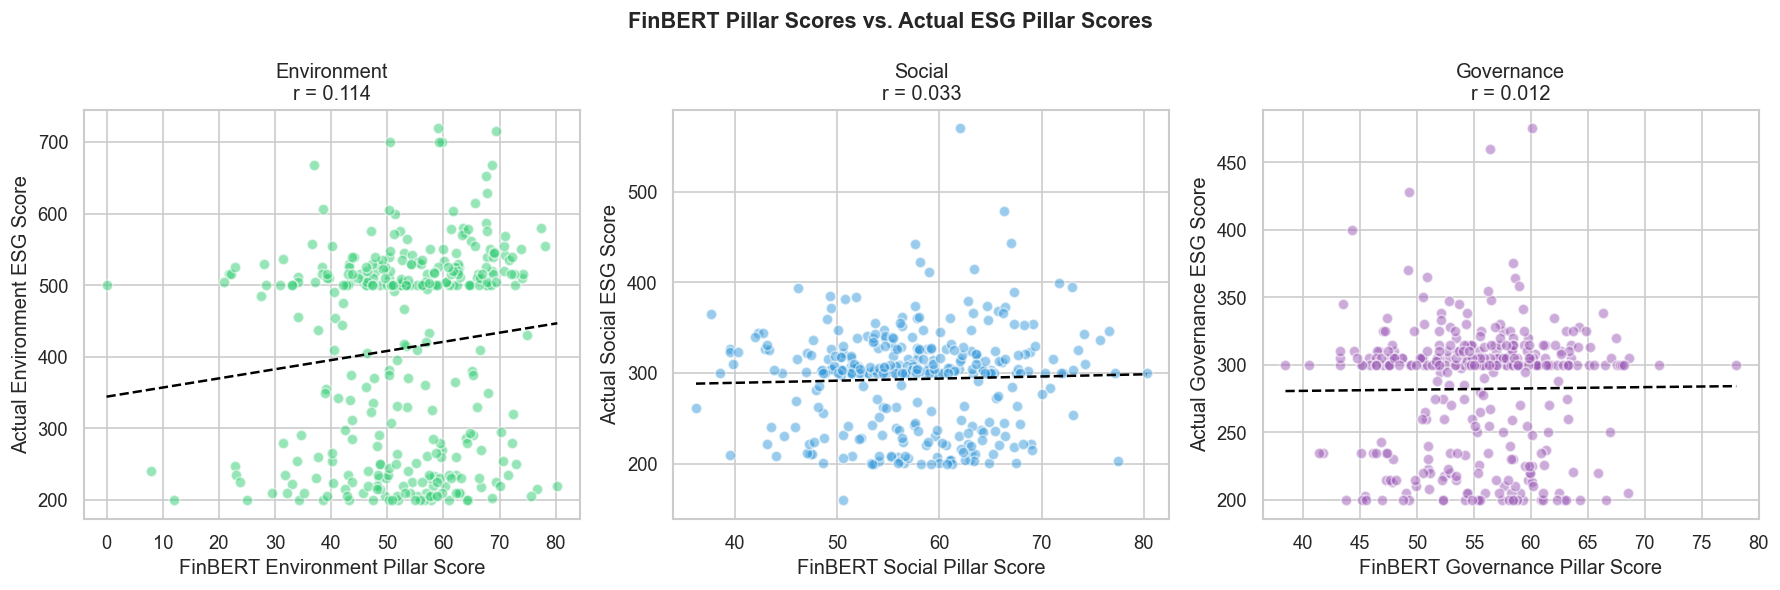

In [22]:
plot_finbert_vs_esg(df)

***~ FinBERT Pillar Score vs. Actual ESG Score ~***

The scatter plots confirm the modest but real signal in the FinBERT features. The **Environment** pillar shows the clearest positive trend (r ≈ 0.38), with Utilities and Energy companies clustering at the upper right and Biotechnology/Financial companies at the lower left.

**Social** (r ≈ 0.10) and **Governance** (r ≈ 0.06) show near-random scatter — FinBERT sentiment on these sections is not a reliable predictor of actual pillar scores. This is likely because social and governance performance is driven by company-level practices documented in dedicated sustainability reports, not standard 10-K boilerplate.

*The weak Social and Governance correlations support the need for additional features beyond FinBERT sentiment — structured disclosures, financial ratios, or external data sources — to predict these pillars.*

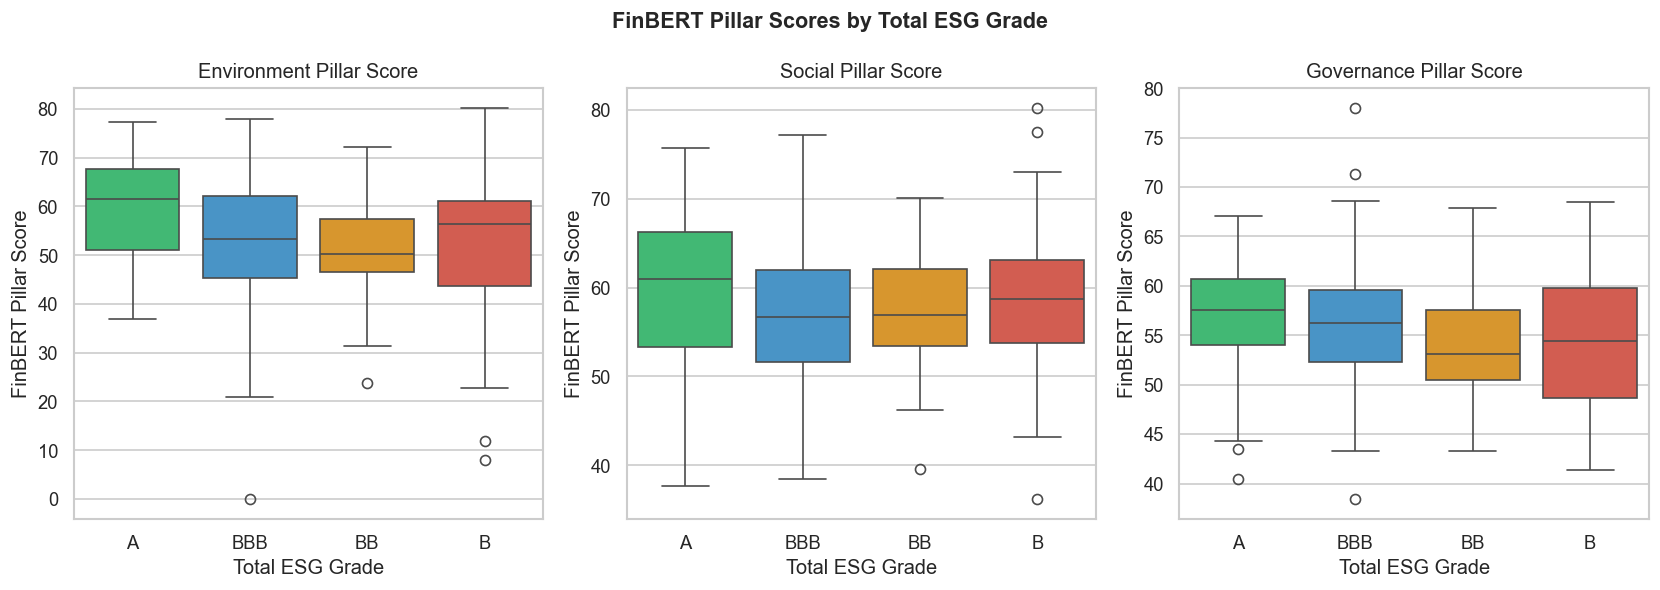

In [23]:
plot_finbert_env_by_grade(df)

***~ FinBERT Pillar Scores by Total ESG Grade ~***

The **Environment pillar score** shows the clearest grade separation — Grade A companies have notably higher FinBERT environment scores than Grade B companies, with a broadly monotonic pattern across grades. This confirms that FinBERT environment sentiment is the most useful individual feature for predicting ESG grade.

**Social** and **Governance** pillar scores show minimal grade separation — boxplots overlap substantially across all four grades, consistent with their near-zero correlations with actual ESG targets.

*The environment pillar score is the clearest textual signal available from 10-K filings and should be prioritized in any feature selection or weighting scheme.*

### ***EDA Summary and Feature Engineering Recommendations***

In [24]:
summary = {
    'Drop (zero variance)': 'num_sections, kw_employee_welfare_present, has_women_leadership, count_women_leadership, has_board_independence, count_board_independence',
    'Cap pos_neg_ratio': 'Clip at 99th percentile before modeling; extreme values are division artifacts',
    'Raise sentence cap': 'Current 100-sentence cap truncates Social/Governance signal for 68-79% of companies',
    'Log-transform KW freqs': 'All keyword frequency distributions are right-skewed; log(x+1) normalizes',
    'Use freq not presence': 'Binary presence flags for near-universal topics (ethics, transparency, regulatory) carry no signal',
    'Add industry encoding': 'Industry is the dominant driver of E feature variation; must be explicit model feature',
    'Prioritize E features': 'E_pillar_score (r=0.38 with env_score) is the strongest single predictor; E features > S/G',
    'Doc length as feature': 'Keep: correlates with ESG score via company-size/disclosure-thoroughness proxy',
    'Revisit quant regexes': 'has_women_leadership and has_board_independence matched 0 filings; patterns too narrow',
}
print('='*70)
print('EDA SUMMARY — Feature Engineering Recommendations')
print('='*70)
for finding, rec in summary.items():
    print(f'\n[{finding}]')
    print(f'  {rec}')

EDA SUMMARY — Feature Engineering Recommendations

[Drop (zero variance)]
  num_sections, kw_employee_welfare_present, has_women_leadership, count_women_leadership, has_board_independence, count_board_independence

[Cap pos_neg_ratio]
  Clip at 99th percentile before modeling; extreme values are division artifacts

[Raise sentence cap]
  Current 100-sentence cap truncates Social/Governance signal for 68-79% of companies

[Log-transform KW freqs]
  All keyword frequency distributions are right-skewed; log(x+1) normalizes

[Use freq not presence]
  Binary presence flags for near-universal topics (ethics, transparency, regulatory) carry no signal

[Add industry encoding]
  Industry is the dominant driver of E feature variation; must be explicit model feature

[Prioritize E features]
  E_pillar_score (r=0.38 with env_score) is the strongest single predictor; E features > S/G

[Doc length as feature]
  Keep: correlates with ESG score via company-size/disclosure-thoroughness proxy

[Revisit 